In [1]:
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib
matplotlib.use('Agg')
import warnings
import pandas as pd
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
from plotnine import *
import statsmodels.formula.api as smf


#Set random seeds
seed = 210226
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="white", font_scale=1.2)

In [2]:
#####-------FILENAMES ETC--------------
dataset_name = "bch" 
raw_file_name = "preprocessed-visits-with-raw-variables"
load_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/"
save_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/"
split_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/epi-and-prediction/prediction/recent-eval/at-triage/"

raw_filepath = "/Users/helenacoggan/mnt/chip-lacava-e2/Groups/BCH-ED/raw-data/"


####--------PREPROCESSING VARIABLES------------

#Define identifier columns.
identifier_cols = ["csn", "is_admitted", "mrn", "minutes_since_first_arrival", "raw_arrival_month", "raw_arrival_year"]

#Define excluded columns-- we do not use these as predictors.
excluded_columns = identifier_cols + ["group", "assigned_order"] #These are excluded from both predictions and IPW calculations.
excluded_prefixes = ['current_diagnosis'] #These are excluded from just predictions.

#Identify gendered predictions; we exclude these when matching patients across sex-based groups
gendered_predictors = ['current_diagnosis_menstrual_disorders', 'pre_diagnosis_menstrual_disorders', 'complaint_contains_abdominal_pain',
                       'complaint_contains_gynecologic', 'complaint_contains_male_genital', 'complaint_contains_pregnancy']

#Separate categorical, pre-binarised, and continuous predictors.
categorical_predictors = [
    'race', 'sex', 'ed_arrival_mode', 'language',
                'insurance', 'home_state', 'year_of_arrival', 'season', 'time_of_day', 'triage_acuity']



#Variables which already 'come pre-binarised'.
pre_binarised_predictors = ['is_trans_or_nb', 'is_weekend',
                            'current_diagnosis_epilepsy', 'current_diagnosis_asthma', 'current_diagnosis_congenital_malformations', 
                'current_diagnosis_depression', 'current_diagnosis_pain_conditions', 'current_diagnosis_anxiety',
                  'current_diagnosis_conduct_disorders', 'current_diagnosis_nausea_and_vomiting',
                    'current_diagnosis_any_malignancy', 'current_diagnosis_gastrointestinal', 
                    'current_diagnosis_developmental_delays', 'current_diagnosis_psychotic_disorders', 
                    'current_diagnosis_cardiovascular', 'current_diagnosis_diabetes_mellitus', 'current_diagnosis_eating_disorders', 
                    'current_diagnosis_weight_loss', 'current_diagnosis_anemia', 'current_diagnosis_chromosomal_anomalies', 
                    'current_diagnosis_drug_abuse', 'current_diagnosis_menstrual_disorders', 'current_diagnosis_sleep_disorders', 
                    'current_diagnosis_smoking', 'current_diagnosis_alcohol_abuse', 'current_diagnosis_joint_disorders', 
                      'pre_diagnosis_any_malignancy', 'pre_diagnosis_gastrointestinal', 'pre_diagnosis_nausea_and_vomiting', 
                      'pre_diagnosis_diabetes_mellitus', 'pre_diagnosis_pain_conditions', 'pre_diagnosis_cardiovascular',
                        'pre_diagnosis_developmental_delays', 'pre_diagnosis_epilepsy', 'pre_diagnosis_asthma', 'pre_diagnosis_anemia', 
                        'pre_diagnosis_congenital_malformations', 'pre_diagnosis_conduct_disorders', 'pre_diagnosis_chromosomal_anomalies',
                          'pre_diagnosis_anxiety', 'pre_diagnosis_weight_loss', 'pre_diagnosis_psychotic_disorders', 'pre_diagnosis_drug_abuse',
                            'pre_diagnosis_smoking', 'pre_diagnosis_depression', 'pre_diagnosis_eating_disorders', 'pre_diagnosis_menstrual_disorders', 
                            'pre_diagnosis_sleep_disorders', 'pre_diagnosis_joint_disorders', 'pre_diagnosis_alcohol_abuse', 
                            'complaint_contains_abdominal_pain', 'complaint_contains_assault', 
                            'complaint_contains_allergic_reaction', 'complaint_contains_altered_mental_status',
                              'complaint_contains_asthma_or_wheezing', 'complaint_contains_bites_or_stings', 
                              'complaint_contains_burn', 'complaint_contains_cardiac', 'complaint_contains_chest_pain', 
                              'complaint_contains_chronic_disease', 'complaint_contains_congestion', 'complaint_contains_constipation', 
                              'complaint_contains_cough', 'complaint_contains_croup', 'complaint_contains_crying_or_colic', 'complaint_contains_dental', 
                              'complaint_contains_device_complication', 'complaint_contains_diarrhea', 'complaint_contains_ear_complaint',
                                'complaint_contains_epistaxis', 'complaint_contains_extremity', 'complaint_contains_eye_complaint', 
                                'complaint_contains_syncope', 'complaint_contains_foreign_body', 'complaint_contains_fever', 
                                'complaint_contains_follow_up', 'complaint_contains_general', 'complaint_contains_gi_bleed',
                                  'complaint_contains_gynecologic', 'complaint_contains_head_or_neck', 'complaint_contains_headache', 
                                  'complaint_contains_laceration', 'complaint_contains_lump_or_mass', 'complaint_contains_male_genital', 
                                  'complaint_contains_mvc', 'complaint_contains_neck_pain', 'complaint_contains_neurologic', 
                                  'complaint_contains_poisoning', 'complaint_contains_poor_feeding', 'complaint_contains_pregnancy', 
                                  'complaint_contains_primary_care', 'complaint_contains_psych', 'complaint_contains_rash', 
                                  'complaint_contains_other_respiratory', 'complaint_contains_seizure', 'complaint_contains_sore_throat',
                                    'complaint_contains_trauma', 'complaint_contains_urinary', 'complaint_contains_vomiting',
                    ]


#Continuous predictors.
continuous_predictors = [
    'age_in_days', 'miles_travelled', 'sdi_score',
     'crowdedness',  'raw_weight', 
     'num_previous_admissions', 'num_previous_visits_without_admission',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2',
]



#Map races into groups.
race_dict = {
    'Hispanic': 'H',
    'Hispanic White': 'H',
    'Black': 'NHB',
    'Non-Hispanic Black': 'NHB',
    'Asian' : 'Other',
    'Unknown': 'Other',
    'Other': 'Other',
    'White': 'NHW',
    'Non-Hispanic White' : 'NHW'
}




Try to fit a model of individual ED LOS based on their own triage acuity and the triage acuity of those around them. For this, we need a sense of the burden at every arrival point. 

In [93]:
#Load the visits for these projects.
visits = pd.read_csv(save_filepath + 'intermediate-files/visits.csv', index_col=0)


#Classify visits into urgent and non-urgent. (Assume that everyone with no recorded triage acuity is non-urgent).
visits['urgent'] = ((~visits['triage_acuity'].isna()) & ((visits['triage_acuity'] == 1) | (visits['triage_acuity'] == 2))).astype(int)

#Now all we need is the admission status, urgency status, ED LOS and timeline of arrival.
visit_timeline = visits[['csn', 'urgent', 'is_admitted', 'ed_los', 'minutes_since_first_arrival']].copy().sort_values('minutes_since_first_arrival')

#So we need to keep a running count of how many urgent, non-urgent, admitted and non-admitted patients (that's a 4-way contingency table) there are in the ED at any given time.
visit_timeline['visit_type'] = np.char.add(
    np.char.add(
        np.where(visit_timeline['urgent'] == 1, 'urgent', 'non-urgent'),
        '-'
    ),
    np.where(visit_timeline['is_admitted'] == 1, 'admitted', 'discharged')
)

#Denote timestamps.
visit_timeline = visit_timeline.rename(columns={'minutes_since_first_arrival':'arrival'})
visit_timeline['departure'] = visit_timeline['arrival'] + visit_timeline['ed_los']

#Now get a list of events (arrivals/departures)
events = visit_timeline[['visit_type', 'arrival', 'departure']].melt(
    id_vars=['visit_type'],
    value_vars=['arrival', 'departure'],
    var_name='event',
    value_name='timestamp'
).sort_values('timestamp')


#Now expand the dataframe.
visit_types, event_types, timestamps = events['visit_type'].values, np.where(events['event'].values=='arrival', 1, -1), events['timestamp'].values

#Store crowding information in a dictionary. (This will contain information on repeat timestamps; we can deal with that later)
crowding_history, crowding_current = {}, {}
vtypes = events['visit_type'].unique()
for vtype in vtypes:
    crowding_history[vtype] = np.zeros_like(timestamps) #Number of visits of each type at each [UNIQUE] timestamp- about 10% of timestamps have repeat events
    crowding_current[vtype] = 0 #Instantaneous count of visits in the ED, starting at 0

for index, ts in enumerate(timestamps):
    vtype, etype = visit_types[index], event_types[index]
    for vtype_ in vtypes:
        if vtype == vtype_: #If this is the relevant type:
            new_crowding = crowding_current[vtype_] + etype #Update population.
        else:
            new_crowding = crowding_current[vtype_] #Use last known population.
        
        #Now update the current population.
        crowding_history[vtype_][index] = new_crowding
        crowding_current[vtype_] = new_crowding


#Now make a dataframe out of the crowding history.
crowding_history['timestamp'] = timestamps
crowding_history = pd.DataFrame(crowding_history).reset_index()

#Now just keep the last instance of all unique timestamps (we only need to know how things stood at the end of the minute, once all relevant processes have played out).
indices_to_keep = crowding_history[['timestamp', 'index']].groupby('timestamp').agg('max').reset_index()
crowding_history = crowding_history.merge(indices_to_keep[['index']], on='index', how='inner').reset_index(drop=True).drop(columns=['index'])

#Save this.
crowding_history.to_csv(save_filepath+'crowding-history.csv')

#Attach this back to visit timeline.
visit_timeline = visit_timeline.merge(crowding_history, left_on='arrival', right_on='timestamp', how='inner').drop(columns=['timestamp', 'departure'])
visit_timeline.to_csv(save_filepath+'visit-timeline.csv')


/var/folders/f0/gwbmx5k5669ffg3gh0_5_k400000gn/T/ipykernel_84117/4290237612.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.


Now see if we can fit a distribution to these 'times-to-arrival'. (If not, the crowding history will nonetheless be helpful for predicting individual level ED-LOS with RNNs, for which we'd need admission status and visit diagnoses).

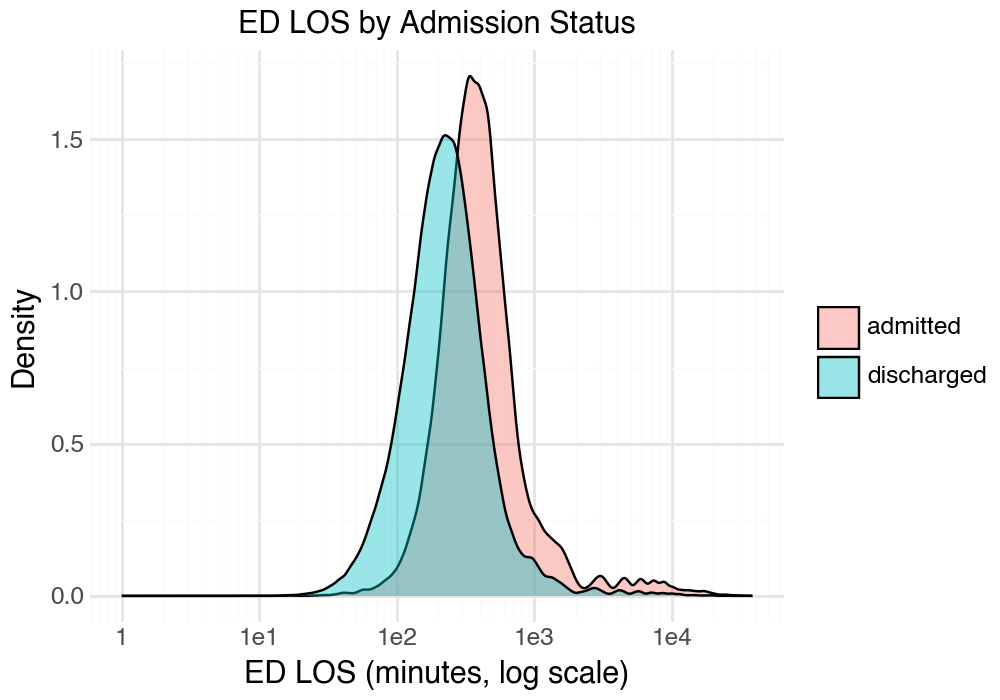

In [94]:
#Load this.
%matplotlib inline
visit_timeline = pd.read_csv(save_filepath+'visit-timeline.csv', index_col=0)

from plotnine import (
    ggplot, aes, geom_density, scale_x_log10,
    labs, theme, theme_minimal, element_text
)

plot_df = visit_timeline.copy()
plot_df['admission_status'] = plot_df['is_admitted'].map({1: 'admitted', 0: 'discharged'})
plot_df['urgency_status'] = plot_df['urgent'].map({1: 'urgent', 0: 'non-urgent'})

def los_density_plot(df, fill_col, title):
    return (
        ggplot(df, aes(x='ed_los', fill=fill_col))
        + geom_density(alpha=0.4)
        + scale_x_log10()
        + labs(title=title, x='ED LOS (minutes, log scale)', y='Density', fill='')
        + theme_minimal()
        + theme(figure_size=(5, 3.5), plot_title=element_text(size=11))
    )

#Plot by admission status.
los_density_plot(plot_df, 'admission_status', 'ED LOS by Admission Status')


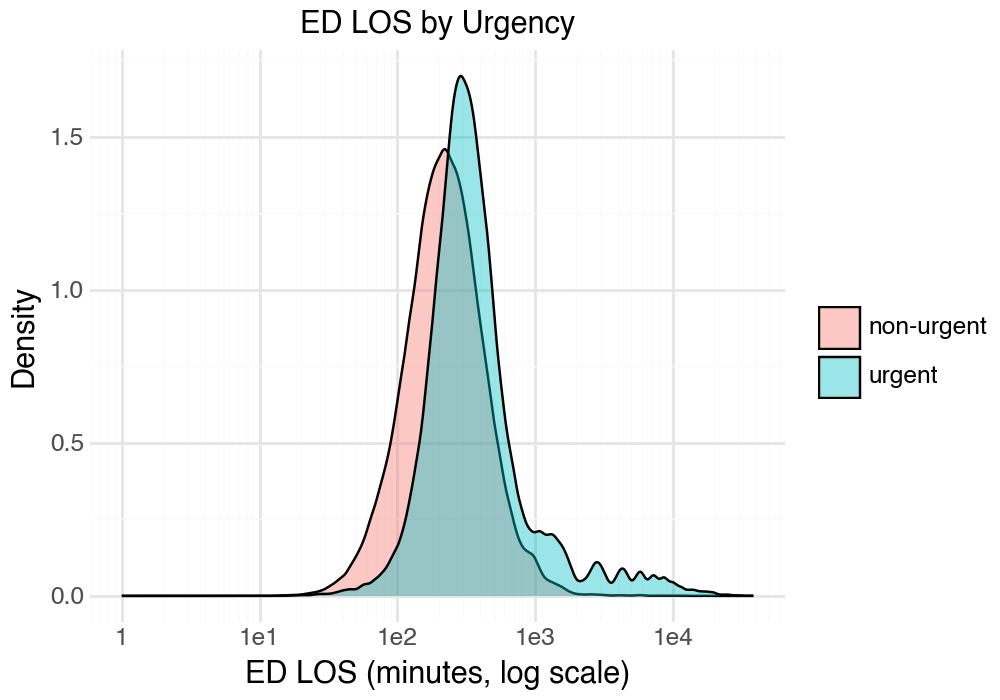

In [95]:
#Plot by urgency.
los_density_plot(plot_df, 'urgency_status', 'ED LOS by Urgency')



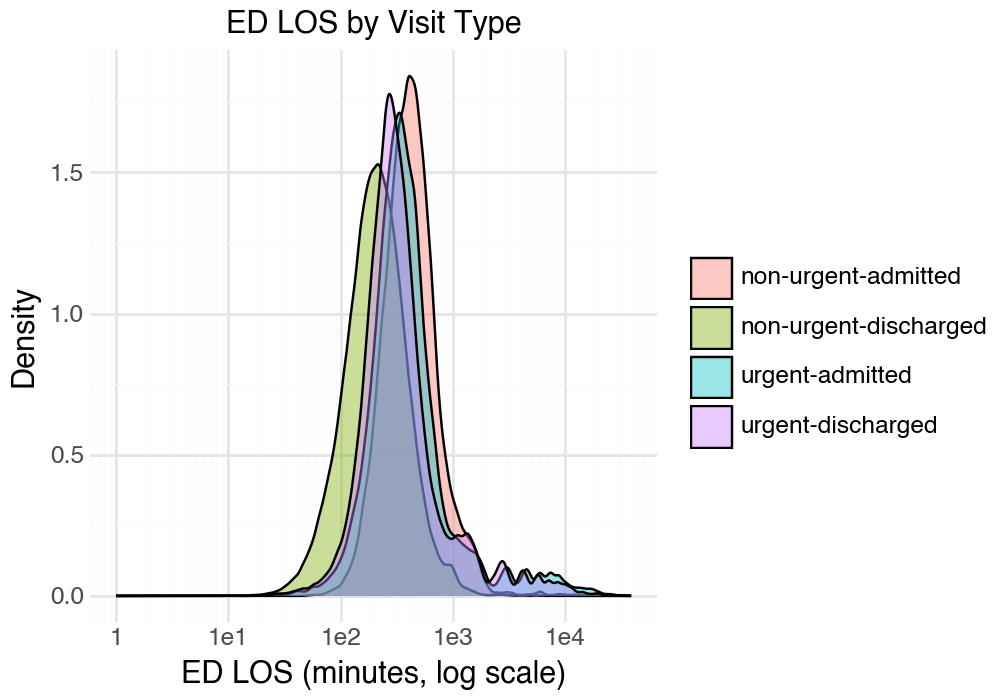

In [96]:
#Plot by visit type.
los_density_plot(plot_df, 'visit_type', 'ED LOS by Visit Type')

Now fit a lognormal distribution to each of these, where a person's wait time depends on their own state and the number of people in every other state.

## Switching to quantile regression

The point-prediction models below (OLS on log(LOS), XGBoost, Random Forest) each collapse the predictive distribution to a single number, then need a bias correction (Duan's smearing estimator) to get back to the original LOS scale. ED length-of-stay is heavily right-skewed and the tails are often what's operationally important (e.g. "how long could this visit run?"), so the cell below refits the same three model families as **quantile regression** models, jointly predicting the 10th/25th/50th/75th/90th percentiles of log(LOS), plus a log-normal AFT survival model as a fourth point of comparison (its quantiles come for free, analytically, once it's fit). Quantiles also commute with the log transform, so no smearing-style correction is needed to get back to LOS in minutes -- one less moving part than the mean-regression version.


In [4]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
from scipy.stats import randint, uniform
from plotnine import (
    ggplot, aes, geom_point, geom_line, geom_ribbon, geom_abline,
    facet_wrap, labs, theme_bw, theme, element_text
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import statsmodels.formula.api as smf
from lifelines import LogNormalAFTFitter
import joblib

RANDOM_STATE = 210226
N_ITER_SEARCH = 10  # number of randomly sampled hyperparameter combos per model

# The conditional quantiles predicted by every model below. 0.5 is the
# median (a robust point forecast); the outer pairs give 50% and 80%
# prediction intervals around it.
QUANTILES = [0.1, 0.25, 0.5, 0.75, 0.9]

# The four ED-crowding features (counts of OTHER concurrently-present
# visits of each type, not a re-encoding of the focal visit's own type --
# visit_type describes the focal visit itself).
CROWDING_COLS = ['non-urgent-discharged', 'urgent-admitted', 'urgent-discharged', 'non-urgent-admitted']

# ----------------------------------------------------------------------
# Load & prep data (unchanged from the point-prediction version)
# ----------------------------------------------------------------------
visit_timeline = pd.read_csv(save_filepath + 'visit-timeline.csv', index_col=0)
raw_visits = pd.read_csv(load_filepath + raw_file_name + ".csv", index_col=0, low_memory=False)
visit_timeline['log_ed_los'] = np.log(visit_timeline['ed_los'])

FEATURE_COLS = (['visit_type'] + CROWDING_COLS + ['is_admitted'] +
                    pre_binarised_predictors + categorical_predictors + continuous_predictors)

df = visit_timeline[['csn', 'visit_type'] + CROWDING_COLS + ['ed_los', 'log_ed_los', 'arrival']].merge(
    raw_visits[['csn', 'is_admitted'] + pre_binarised_predictors + categorical_predictors + continuous_predictors], on='csn', how='inner')

# Single train/test split shared across all models, for a fair comparison (chronological as before)
[X_train, X_test, y_train, y_test, csn_train, csn_test] = joblib.load(save_filepath+"outputs/split.joblib")
max_timestamp = df.merge(csn_train, on='csn', how='inner')['arrival'].max()
train_df, test_df = df[df['arrival'] <= max_timestamp].copy(), df[df['arrival'] > max_timestamp].copy()

train_df.to_csv(save_filepath+'intermediate-files/ed-los-train-df.csv')
test_df.to_csv(save_filepath+'intermediate-files/ed-los-test-df.csv')

# One-hot encoded feature matrices for the sklearn-style models
X_train = pd.get_dummies(train_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = pd.get_dummies(test_df[FEATURE_COLS], columns=['visit_type'] + categorical_predictors, drop_first=False)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)  # guard against unseen categories

y_train = train_df['log_ed_los']
y_test = test_df['log_ed_los']

VISIT_TYPES = sorted(train_df['visit_type'].unique())

# CV splitter shared by both randomized searches, for a fair comparison of
# search results across model families
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------------------------------------------------
# Pinball (quantile) loss: what quantile regression optimises, and the
# natural way to score it out-of-sample. Lower is better.
# ----------------------------------------------------------------------
def pinball_loss(y_true, y_pred, q):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    diff = y_true - y_pred
    return np.mean(np.maximum(q * diff, (q - 1) * diff))

# ----------------------------------------------------------------------
# Every model's test-set predictions get written to their own CSV --
# quantile columns on both the log scale it was fit on and the original
# ed_los scale, plus enough identifying columns to link back to the visit.
# ----------------------------------------------------------------------
os.makedirs(save_filepath + "outputs/predictions", exist_ok=True)

def save_predictions_csv(model_label, test_pred_dict):
    out = pd.DataFrame({
        'csn': test_df['csn'].values,
        'visit_type': test_df['visit_type'].values,
        'actual_log_ed_los': y_test.values,
        'actual_ed_los': test_df['ed_los'].values,
    })
    for q in QUANTILES:
        out[f'pred_q{int(q*100)}_log'] = test_pred_dict[q]
        out[f'pred_q{int(q*100)}_orig'] = np.exp(test_pred_dict[q])
    fname = save_filepath + "outputs/predictions/" + model_label.lower().replace(' ', '_').replace('(', '').replace(')', '') + ".csv"
    out.to_csv(fname, index=False)
    print(f"  saved predictions -> {fname}")
    return fname

# ----------------------------------------------------------------------
# Helper for the "split by visit_type" models: build a formula using only
# the crowding terms that actually vary within a given visit_type's
# training subset. In practice all four should vary (they describe OTHER
# concurrently-present visits, not the focal visit's own type, so there's
# no structural reason for them to be constant within a visit_type group)
# -- this is just a defensive fallback for unusually small/degenerate
# subgroups, where it reduces to an intercept-only fit (i.e. that group's
# own empirical quantile).
# ----------------------------------------------------------------------
def reduced_terms(base_cols, group_df):
    kept = [c for c in base_cols if group_df[c].nunique() > 1]
    return "1" if not kept else " + ".join(f"Q('{c}')" for c in kept)

def build_reduced_formula(base_cols, group_df, response):
    return f"{response} ~ {reduced_terms(base_cols, group_df)}"

# ----------------------------------------------------------------------
# Fit each model family two ways:
#   (pooled)                 one model trained on all visit types together
#   (split by visit_type)    one model per visit_type, predictions combined
#                             back into a single test-set array
# Split models reuse the SAME tuned hyperparameters as their pooled
# counterpart (where relevant), so the comparison isolates the effect of
# splitting by visit_type from the effect of separately re-tuning each
# group -- a fair per-group hyperparameter search would need its own
# (much smaller) RandomizedSearchCV per group, which isn't done here.
# ----------------------------------------------------------------------
preds = {}        # preds[label]['test'][q] = array of predictions (log scale)
best_params = {}  # best_params[model_name] = dict of tuned hyperparameters (pooled search only)

# ======================================================================
# Model 1: Linear quantile regression (statsmodels QuantReg)
# ======================================================================
formula = "log_ed_los ~ visit_type * (Q('non-urgent-discharged') + Q('urgent-admitted') + Q('urgent-discharged') + Q('non-urgent-admitted'))"

# --- pooled ---
lqr_test_pooled = {}
for q in QUANTILES:
    fit = smf.quantreg(formula, data=train_df).fit(q=q, max_iter=5000)
    lqr_test_pooled[q] = fit.predict(test_df).values
preds['Linear QR (pooled)'] = {'test': lqr_test_pooled}
save_predictions_csv('Linear QR (pooled)', lqr_test_pooled)

# --- split by visit_type ---
lqr_test_split = {q: np.empty(len(test_df)) for q in QUANTILES}
for vt in VISIT_TYPES:
    grp_train = train_df[train_df['visit_type'] == vt]
    grp_test_mask = (test_df['visit_type'] == vt).values
    grp_formula = build_reduced_formula(CROWDING_COLS, grp_train, 'log_ed_los')
    for q in QUANTILES:
        fit = smf.quantreg(grp_formula, data=grp_train).fit(q=q, max_iter=5000)
        lqr_test_split[q][grp_test_mask] = fit.predict(test_df[grp_test_mask]).values
preds['Linear QR (split by visit_type)'] = {'test': lqr_test_split}
save_predictions_csv('Linear QR (split by visit_type)', lqr_test_split)

# ======================================================================
# Model 2: XGBoost, native multi-quantile regression
# ======================================================================
median_pinball_scorer = make_scorer(lambda yt, yp: -pinball_loss(yt, yp, 0.5)) #for randomised-search-cv

xgb_param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(2, 10),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 2),
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(objective='reg:quantileerror', quantile_alpha=0.5,
                            random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER_SEARCH,
    scoring=median_pinball_scorer, 
    cv=cv_splitter,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=2,
)
xgb_search.fit(X_train, y_train)
best_params['XGBoost'] = xgb_search.best_params_

# --- pooled: refit with the tuned hyperparameters, predicting all quantiles jointly ---
xgb_model_pooled = XGBRegressor(objective='reg:quantileerror', quantile_alpha=np.array(QUANTILES),
                                 random_state=RANDOM_STATE, n_jobs=-1, **best_params['XGBoost'])
xgb_model_pooled.fit(X_train, y_train)
xgb_test_pooled_arr = xgb_model_pooled.predict(X_test)  # (n, len(QUANTILES))
xgb_test_pooled = {q: xgb_test_pooled_arr[:, i] for i, q in enumerate(QUANTILES)}
preds['XGBoost (pooled)'] = {'test': xgb_test_pooled}
save_predictions_csv('XGBoost (pooled)', xgb_test_pooled)

# --- split by visit_type: same tuned hyperparameters, one model per group ---
xgb_test_split = {q: np.empty(len(test_df)) for q in QUANTILES}
for vt in VISIT_TYPES:
    grp_train_mask = (train_df['visit_type'] == vt).values
    grp_test_mask = (test_df['visit_type'] == vt).values
    grp_model = XGBRegressor(objective='reg:quantileerror', quantile_alpha=np.array(QUANTILES),
                              random_state=RANDOM_STATE, n_jobs=-1, **best_params['XGBoost'])
    grp_model.fit(X_train[grp_train_mask], y_train[grp_train_mask])
    grp_pred_arr = grp_model.predict(X_test[grp_test_mask])
    for i, q in enumerate(QUANTILES):
        xgb_test_split[q][grp_test_mask] = grp_pred_arr[:, i]
preds['XGBoost (split by visit_type)'] = {'test': xgb_test_split}
save_predictions_csv('XGBoost (split by visit_type)', xgb_test_split)

# ======================================================================
# Model 3: Random Forest -> Quantile Regression Forest (Meinshausen, 2006)
# ======================================================================
rf_param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': randint(3, 30),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': uniform(0.3, 0.7),
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    param_distributions=rf_param_dist,
    n_iter=N_ITER_SEARCH,
    scoring='neg_mean_squared_error',
    cv=cv_splitter,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=2,
)
rf_search.fit(X_train, y_train)
rf_model_pooled = rf_search.best_estimator_
best_params['Random Forest'] = rf_search.best_params_

def rf_quantile_predict(rf_model, X_leaf_source, y_leaf_source, X_query, quantiles):
    """
    Quantile Regression Forest predictions. For each query point, weight
    every TRAINING y-value by the fraction of trees in which it shares a
    leaf with the query point, then read off a weighted empirical quantile
    of those y-values.
    """
    leaf_ids_source = rf_model.apply(X_leaf_source)
    leaf_ids_query = rf_model.apply(X_query)
    y_arr = np.asarray(y_leaf_source)
    out = {q: np.empty(X_query.shape[0]) for q in quantiles}
    for i in range(X_query.shape[0]):
        weights = (leaf_ids_source == leaf_ids_query[i]).mean(axis=1)
        mask = weights > 0
        w, y_vals = weights[mask], y_arr[mask]
        order = np.argsort(y_vals)
        y_sorted, w_sorted = y_vals[order], w[order]
        cum_w = np.cumsum(w_sorted) / w_sorted.sum()
        for q in quantiles:
            idx = min(np.searchsorted(cum_w, q), len(y_sorted) - 1)
            out[q][i] = y_sorted[idx]
    return out

# --- pooled ---
rf_test_pooled = rf_quantile_predict(rf_model_pooled, X_train.values, y_train.values, X_test.values, QUANTILES)
preds['Quantile RF (pooled)'] = {'test': rf_test_pooled}
save_predictions_csv('Quantile RF (pooled)', rf_test_pooled)

# --- split by visit_type: same tuned hyperparameters, one forest per group ---
rf_test_split = {q: np.empty(len(test_df)) for q in QUANTILES}
for vt in VISIT_TYPES:
    grp_train_mask = (train_df['visit_type'] == vt).values
    grp_test_mask = (test_df['visit_type'] == vt).values
    grp_X_train = X_train.values[grp_train_mask]
    grp_y_train = y_train.values[grp_train_mask]
    grp_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **best_params['Random Forest'])
    grp_model.fit(grp_X_train, grp_y_train)
    grp_preds = rf_quantile_predict(grp_model, grp_X_train, grp_y_train, X_test.values[grp_test_mask], QUANTILES)
    for q in QUANTILES:
        rf_test_split[q][grp_test_mask] = grp_preds[q]
preds['Quantile RF (split by visit_type)'] = {'test': rf_test_split}
save_predictions_csv('Quantile RF (split by visit_type)', rf_test_split)

# Save the winning (pooled) hyperparameters + pooled models -- split models
# aren't persisted individually since they're cheap to refit from these
# same tuned hyperparameters.
joblib.dump(best_params, save_filepath + "outputs/tuned_hyperparameters_qr.joblib")
joblib.dump(xgb_model_pooled, save_filepath + "outputs/xgb_model_quantile.joblib")
joblib.dump(rf_model_pooled, save_filepath + "outputs/rf_model_quantile.joblib")

print("Best XGBoost params:", best_params['XGBoost'])
print("Best Random Forest params:", best_params['Random Forest'])

# ----------------------------------------------------------------------
# Metrics: pinball loss per quantile and empirical coverage, for every
# pooled/split pair, so the plots and summary table directly compare them.
# ----------------------------------------------------------------------
def compute_quantile_metrics(y_true, quantile_preds, quantiles):
    y_true = np.asarray(y_true)
    rows = []
    for q in quantiles:
        y_pred = np.asarray(quantile_preds[q])
        mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
        yt, yp = y_true[mask], y_pred[mask]
        rows.append({
            'quantile': q, 'n': mask.sum(),
            'pinball_loss': pinball_loss(yt, yp, q),
            'coverage': np.mean(yt <= yp),
        })
    return pd.DataFrame(rows)

def median_errors(y_true, quantile_preds):
    y_true = np.asarray(y_true)
    y_med = np.asarray(quantile_preds[0.5])
    mask = ~np.isnan(y_true) & ~np.isnan(y_med)
    err = y_true[mask] - y_med[mask]
    return {'MAE_median': np.mean(np.abs(err)), 'RMSE_median': np.sqrt(np.mean(err ** 2))}

summary_rows = []
for model_name, p in preds.items():
    metrics_df = compute_quantile_metrics(y_test.values, p['test'], QUANTILES)
    metrics_df['model'] = model_name
    summary_rows.append(metrics_df)
    med_err = median_errors(y_test.values, p['test'])
    print(f"{model_name}: median MAE={med_err['MAE_median']:.3f}  median RMSE={med_err['RMSE_median']:.3f}  "
          f"mean pinball={metrics_df['pinball_loss'].mean():.4f}")

metrics_long = pd.concat(summary_rows, ignore_index=True)

# Simple pooled-vs-split summary table: is splitting by visit_type worth it?
summary_wide = (
    metrics_long.groupby('model')['pinball_loss'].mean()
    .rename('mean_pinball_loss').reset_index()
)
summary_wide['family'] = summary_wide['model'].str.replace(r' \((pooled|split by visit_type)\)', '', regex=True)
summary_wide['variant'] = np.where(summary_wide['model'].str.contains('split'), 'split', 'pooled')
comparison_table = summary_wide.pivot(index='family', columns='variant', values='mean_pinball_loss')
comparison_table['split_minus_pooled'] = comparison_table['split'] - comparison_table['pooled']
print("\nMean pinball loss, pooled vs. split by visit_type (negative = split is better):")
print(comparison_table.round(4))

# ----------------------------------------------------------------------
# Plot 1: pinball loss by quantile, per model (test set)
# ----------------------------------------------------------------------
p_pinball = (
    ggplot(metrics_long, aes(x='quantile', y='pinball_loss', color='model'))
    + geom_line(size=1) + geom_point(size=2)
    + labs(title='Pinball loss by quantile: pooled vs. split by visit_type (test set, log scale)',
           x='Quantile', y='Pinball loss')
    + theme_bw()
)
p_pinball.show()

# ----------------------------------------------------------------------
# Plot 2: calibration -- nominal vs. empirical coverage
# ----------------------------------------------------------------------
p_calib = (
    ggplot(metrics_long, aes(x='quantile', y='coverage', color='model'))
    + geom_line(size=1) + geom_point(size=2)
    + geom_abline(slope=1, intercept=0, linetype='dashed', color='black')
    + labs(title='Calibration: nominal vs. empirical coverage, pooled vs. split (test set)',
           x='Nominal quantile', y='Empirical coverage (fraction of actual <= predicted)')
    + theme_bw()
)
p_calib.show()

# ----------------------------------------------------------------------
# Plot 3: predicted quantiles (10/25/50/75/90%) vs. actual, sorted by
# predicted median, one facet per pooled/split model.
# ----------------------------------------------------------------------
def build_interval_df(scale='log'):
    rows = []
    for model_name, p in preds.items():
        chunk = pd.DataFrame({
            'actual_log': y_test.values,
            'actual_orig': test_df['ed_los'].values,
        })
        for q in QUANTILES:
            chunk[f'q{int(q*100)}_log'] = p['test'][q]
            chunk[f'q{int(q*100)}_orig'] = np.exp(p['test'][q])
        chunk['model'] = model_name
        rows.append(chunk)
    long_df = pd.concat(rows, ignore_index=True)
    suffix = 'log' if scale == 'log' else 'orig'
    long_df = long_df.rename(columns={f'actual_{suffix}': 'actual'})
    for q in QUANTILES:
        long_df = long_df.rename(columns={f'q{int(q*100)}_{suffix}': f'q{int(q*100)}'})
    return long_df

def plot_intervals(scale='log', scale_label='', sample_n=1000):
    plot_df = build_interval_df(scale=scale)
    sampled = []
    for model_name, g in plot_df.groupby('model'):
        g = g.sample(min(sample_n, len(g)), random_state=RANDOM_STATE).sort_values('q50')
        g = g.reset_index(drop=True)
        g['idx'] = np.arange(len(g))
        sampled.append(g)
    plot_df = pd.concat(sampled, ignore_index=True)
    p = (
        ggplot(plot_df, aes(x='idx'))
        + geom_ribbon(aes(ymin='q10', ymax='q90'), fill='steelblue', alpha=0.25)
        + geom_ribbon(aes(ymin='q25', ymax='q75'), fill='steelblue', alpha=0.4)
        + geom_line(aes(y='q50'), color='steelblue', size=0.8)
        + geom_point(aes(y='actual'), alpha=0.3, size=0.6, color='black')
        + facet_wrap('~model', ncol=2)
        + labs(title=f'Predicted quantiles (10/25/50/75/90%) vs. actual, sorted by median ({scale_label})',
               x='Test-set visits, sorted by predicted median', y=scale_label)
        + theme_bw()
        + theme(figure_size=(12, 16), strip_text=element_text(size=9))
    )
    return p

p_intervals_log = plot_intervals(scale='log', scale_label='log(ed_los)')
p_intervals_log.show()

p_intervals_orig = plot_intervals(scale='orig', scale_label='ed_los (min)')
p_intervals_orig.show() th

  saved predictions -> /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/predictions/linear_qr_pooled.csv
  saved predictions -> /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/predictions/linear_qr_split_by_visit_type.csv
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END colsample_bytree=0.8543759773368536, learning_rate=0.24307772206843534, max_depth=8, min_child_weight=8, n_estimators=130, reg_alpha=0.2033708730997611, reg_lambda=0.9720326832691788, subsample=0.6296164427825944; total time=   5.6s
[CV] END colsample_bytree=0.8543759773368536, learning_rate=0.24307772206843534, max_depth=8, min_child_weight=8, n_estimators=130, reg_alpha=0.2033708730997611, reg_lambda=0.9720326832691788, subsample=0.6296164427825944; total time=   6.6s
[CV] END colsample_bytree=0.8543759773368536, learning_rate=0.24307772206843534, max_depth=8, min_child_weight=8, n_estimators=130, reg_alpha=0.2033708730997611

/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


[CV] END max_depth=25, max_features=0.41525942124168586, min_samples_leaf=6, min_samples_split=3, n_estimators=537; total time= 6.8min
[CV] END max_depth=25, max_features=0.41525942124168586, min_samples_leaf=6, min_samples_split=3, n_estimators=537; total time= 6.9min
[CV] END max_depth=25, max_features=0.41525942124168586, min_samples_leaf=6, min_samples_split=3, n_estimators=537; total time= 6.9min
[CV] END max_depth=25, max_features=0.41525942124168586, min_samples_leaf=6, min_samples_split=3, n_estimators=537; total time= 6.9min
[CV] END max_depth=25, max_features=0.41525942124168586, min_samples_leaf=6, min_samples_split=3, n_estimators=537; total time= 6.9min
[CV] END max_depth=20, max_features=0.8583571040004383, min_samples_leaf=1, min_samples_split=13, n_estimators=289; total time= 6.9min
[CV] END max_depth=23, max_features=0.40154648334877946, min_samples_leaf=1, min_samples_split=9, n_estimators=124; total time= 1.6min
[CV] END max_depth=20, max_features=0.8583571040004383,

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names


  saved predictions -> /Users/helenacoggan/mnt/chip-lacava-e2/Groups/ch265493/BCH-ED/decompensation/outputs/predictions/quantile_rf_pooled.csv


KeyboardInterrupt: 

Same idea for the LSTM: the output head now emits all five quantiles at every timestep (constrained to be non-decreasing so they can't cross), trained with the pinball loss instead of MSE. Everything else -- age-banded normalization, categorical encoding, truncated-BPTT windowing, and the Optuna search -- is unchanged from the original script; only the model head, loss function, and evaluation metrics differ.


In [15]:
"""
LSTM for ED Length-of-Stay prediction, modeled as a causal sequence of visits
ordered by arrival time (captures crowding/queue dynamics via hidden state).

QUANTILE REGRESSION VERSION: instead of a single MSE-trained output per
timestep, the head now emits one value per entry in Config.quantiles,
trained jointly with the pinball (quantile) loss. Quantiles are enforced to
be non-decreasing by construction (see LSTMLosModel.forward), which avoids
"quantile crossing" -- a common artifact when independent models or heads
are fit per quantile with no shared structure between them.

Now includes an Optuna study that tunes architecture/optimization
hyperparameters (hidden_dim, lstm_layers, dropout, lr, weight_decay,
batch_size, window_len) against validation loss, with median pruning to
kill off clearly-bad trials early. Data preprocessing (encoders, scaler,
feature engineering) is done ONCE up front and shared across all trials -
only the dataset windowing, model, and optimizer are rebuilt per trial -
so tuning doesn't redo the expensive train-only-fit steps 1e.g. 50 times.

Assumptions baked into this script (adjust to your data):
  - One dataframe per site, already sorted (or sortable) by arrival time.
    If you have multiple sites, run this pipeline separately per site, or
    add a site_id categorical feature AND reset hidden state at site boundaries.
  - timestamp_col is a NUMERIC "minutes since first arrival" index, not a
    datetime. If you also know the real calendar datetime of the first
    arrival, set Config.reference_start_datetime to reconstruct hour-of-day /
    day-of-week cyclical features; otherwise those are skipped automatically.
  - Target: LOS in minutes -> log1p-transformed for training (MSE loss on
    the log scale, back-transformed via expm1 for reporting).
  - Retrospective setting: fine to use disposition/admission status as a
    feature, since prediction is made after discharge, not at triage.
  - categorical_predictors are TEXT/STRING categories and need explicit
    integer encoding (fit on train_df only, with an "unseen" fallback bucket
    for categories that only appear in test_df).
  - pre_binarised_predictors and is_admitted are already 0/1 binary flags -
    these are treated as NUMERIC inputs, not embedded. Embedding a 2-state
    variable adds parameters for no benefit; a raw 0/1 (or its z-score)
    already represents it fully.
  - Truncated BPTT: sequences are chunked into windows; the LSTM hidden
    state is carried across consecutive windows of the same sequence and
    detached between windows to cap the backprop graph size.

Fill in continuous_predictors / categorical_predictors / pre_binarised_predictors
and the file paths in the RUN section at the bottom, then execute.

Requires: pip install optuna
"""

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import optuna
from optuna.pruners import MedianPruner


# --------------------------------------------------------------------------
# Age banding for age-specific vital-sign normalization.
#
# Pediatric vitals (HR, RR, BP, etc.) have very different normal ranges by
# age - a heart rate that's normal for a 2-month-old is a tachycardia for a
# 10-year-old. Z-scoring across the whole population would wash that out, so
# age-dependent columns get their mean/std/median computed WITHIN each band
# instead of globally. Bin edges are in days for exact, unambiguous cutoffs.
# --------------------------------------------------------------------------
DAYS_PER_MONTH = 30.4375   # 365.25 / 12, for unambiguous month cutoffs
DAYS_PER_YEAR = 365.25

AGE_BIN_EDGES_DAYS = [
    0,
    3 * DAYS_PER_MONTH,
    6 * DAYS_PER_MONTH,
    12 * DAYS_PER_MONTH,
    18 * DAYS_PER_MONTH,
    36 * DAYS_PER_MONTH,
    5 * DAYS_PER_YEAR,
    10 * DAYS_PER_YEAR,
    15 * DAYS_PER_YEAR,
    np.inf,
]
AGE_BIN_LABELS = [
    "0-3mo", "3-6mo", "6-12mo", "12-18mo", "18-36mo",
    "3-5y", "5-10y", "10-15y", "15+",
]
UNKNOWN_AGE_GROUP = "unknown"  # fallback bucket for missing/out-of-range ages


def assign_age_group(df: pd.DataFrame, age_col: str, age_group_col: str = "age_group") -> pd.DataFrame:
    """
    Adds an age_group categorical column from a numeric age_in_days column.
    Bins are left-inclusive/right-exclusive (e.g. "0-3mo" = [0, 3mo)).
    Missing or negative/invalid ages fall back to a shared "unknown" bucket
    rather than becoming NaN, so every row still has a usable group.
    """
    df = df.copy()
    age_days = df[age_col]
    group = pd.cut(age_days, bins=AGE_BIN_EDGES_DAYS, labels=AGE_BIN_LABELS,
                    right=False, include_lowest=True)
    df[age_group_col] = group.astype(object)
    df[age_group_col] = df[age_group_col].where(age_days.notna() & (age_days >= 0), UNKNOWN_AGE_GROUP)
    df[age_group_col] = df[age_group_col].fillna(UNKNOWN_AGE_GROUP)
    return df


# --------------------------------------------------------------------------
# CONFIG - built dynamically from your predictor lists once train_df is loaded.
# Call build_config(train_df, continuous_predictors, categorical_predictors,
# pre_binarised_predictors) rather than editing a hardcoded class - see RUN
# section at the bottom.
# --------------------------------------------------------------------------
class Config:
    timestamp_col = "arrival"
    los_col = "ed_los"

    # If you know the real-world calendar datetime of the very first arrival,
    # set it here (e.g. pd.Timestamp("2021-01-04 07:12:00")) and hour-of-day /
    # day-of-week cyclical features will be reconstructed automatically.
    # Leave as None to skip those features (inter-arrival gap is still used).
    reference_start_datetime = None

    # These are populated by build_config(); placeholders here just document
    # the shape expected.
    numeric_cols = []          # continuous predictors + binary flags + is_admitted
    categorical_cols = {}      # {col: cardinality including the +1 unknown bucket}
    embedding_dims = {}        # {col: chosen embedding size, < cardinality}
    time_cols = []             # populated at feature-engineering time

    # Age-specific normalization/imputation
    age_col = "age_in_days"
    age_group_col = "age_group"
    age_dependent_cols = set()   # subset of numeric_cols normalized PER age band
    min_age_group_size = 10      # bands with fewer valid train rows fall back to global stats

    # --- Model / training hyperparameters. Defaults below are used when NOT
    # running the Optuna search (e.g. if you just want to train once); the
    # search overwrites a copy of these per-trial and the winning values are
    # copied back in before the final full training run. ---
    hidden_dim = 128
    lstm_layers = 2
    dropout = 0.1

    # Conditional quantiles predicted jointly at every timestep. 0.5 is the
    # median (used as the single point-forecast for MAE/RMSE reporting);
    # the outer values give 50% and 80% prediction intervals.
    quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

    window_len = 100      # visits per truncated-BPTT window
    window_stride = 100   # non-overlapping; reduce for overlap
    batch_size = 16

    lr = 1e-3
    weight_decay = 0.0
    epochs = 20
    device = "cuda" if torch.cuda.is_available() else "cpu"


def build_config(train_df, continuous_predictors, categorical_predictors,
                  pre_binarised_predictors, is_admitted_col="is_admitted",
                  timestamp_col="arrival", los_col="ed_los",
                  reference_start_datetime=None,
                  age_dependent_predictors=None, age_col="age_in_days",
                  min_age_group_size=10, quantiles=None):
    """
    Constructs a Config instance from your predictor lists.

    - continuous_predictors, pre_binarised_predictors, and is_admitted are all
      routed to numeric_cols (binary flags need no embedding).
    - categorical_predictors are TEXT columns -> get integer-encoded (see
      fit_categorical_encoders) and go through embeddings, sized well below
      their cardinality rather than equal to it.
    - age_dependent_predictors: subset of continuous_predictors (typically
      vitals like hr/sbp/dbp/rr/spo2/temp) that should be normalized and
      imputed PER age band (see AGE_BIN_LABELS) rather than globally. Must
      already be part of continuous_predictors - pass age_in_days itself
      separately if you also want raw age as a model feature.
    """
    cfg = Config()
    cfg.timestamp_col = timestamp_col
    cfg.los_col = los_col
    cfg.reference_start_datetime = reference_start_datetime
    cfg.quantiles = list(quantiles) if quantiles is not None else list(Config.quantiles)

    cfg.numeric_cols = list(continuous_predictors) + list(pre_binarised_predictors) + [is_admitted_col]

    cfg.age_col = age_col
    cfg.min_age_group_size = min_age_group_size
    cfg.age_dependent_cols = set(age_dependent_predictors or [])
    unknown_age_dependent = cfg.age_dependent_cols - set(cfg.numeric_cols)
    if unknown_age_dependent:
        raise ValueError(
            f"age_dependent_predictors {sorted(unknown_age_dependent)} are not in "
            f"continuous_predictors/pre_binarised_predictors - add them there first."
        )

    # Cardinality is set once encoders are fit (train-only) - see prepare_train_test.
    # Placeholder here; overwritten in prepare_train_test after encoding.
    cfg.categorical_cols = {col: train_df[col].nunique() + 1 for col in categorical_predictors}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    return cfg


# --------------------------------------------------------------------------
# Categorical encoding: text -> integer codes, fit on train_df ONLY.
# Index 0 is reserved for "unseen/unknown" (categories only in test_df).
# --------------------------------------------------------------------------
def fit_categorical_encoders(train_df: pd.DataFrame, cat_col_names: list) -> dict:
    encoders = {}
    for col in cat_col_names:
        categories = sorted(train_df[col].dropna().astype(str).unique().tolist())
        encoders[col] = {cat: i + 1 for i, cat in enumerate(categories)}  # 0 reserved for unknown
    return encoders


def apply_categorical_encoders(df: pd.DataFrame, cat_col_names: list, encoders: dict) -> pd.DataFrame:
    df = df.copy()
    for col in cat_col_names:
        df[col] = df[col].astype(str).map(encoders[col]).fillna(0).astype(np.int64)
    return df


# --------------------------------------------------------------------------
# Feature engineering
#
# Split into fit_scaler (train_df only) + apply_features (any df), so
# normalization stats and outlier caps never leak from test into train.
# --------------------------------------------------------------------------
def add_time_and_target_features(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    """
    Deterministic features that don't need fitting: safe to apply to any split.

    timestamp_col is a numeric minutes-since-first-arrival index (not a
    datetime). Cyclical hour-of-day / day-of-week features are only added if
    cfg.reference_start_datetime is set; otherwise cfg.time_cols stays empty
    and the model relies on inter-arrival gap alone for temporal context.
    """
    df = df.sort_values(cfg.timestamp_col).reset_index(drop=True)

    if cfg.reference_start_datetime is not None:
        real_ts = cfg.reference_start_datetime + pd.to_timedelta(df[cfg.timestamp_col], unit="m")
        hour = real_ts.dt.hour + real_ts.dt.minute / 60.0
        df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
        df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
        dow = real_ts.dt.dayofweek
        df["dow_sin"] = np.sin(2 * np.pi * dow / 7)
        cfg.time_cols = ["hour_sin", "hour_cos", "dow_sin"]
    else:
        cfg.time_cols = []

    # timestamp_col is already in minutes, so a simple diff gives the gap directly
    df["inter_arrival_gap"] = df[cfg.timestamp_col].diff().fillna(0)

    df["log_los"] = np.log1p(df[cfg.los_col].clip(lower=0))
    return df


def diagnose_missingness(df: pd.DataFrame, numeric_cols: list, los_col: str) -> None:
    """
    Prints NaN/Inf counts per numeric column and the target. Run this on
    train_df and test_df BEFORE training - an LSTM will silently produce
    NaN loss for the entire run if even one row has a missing/infinite value,
    since the hidden state carries the NaN forward through the whole sequence.
    """
    print("--- missingness / infinity check ---")
    any_found = False
    for col in numeric_cols + [los_col]:
        n_nan = df[col].isna().sum()
        n_inf = int(np.isinf(df[col].to_numpy(dtype=float, na_value=0.0)).sum())
        if n_nan or n_inf:
            any_found = True
            print(f"  {col}: {n_nan} NaN, {n_inf} Inf (of {len(df)} rows)")
    if not any_found:
        print("  none found")
    print("-------------------------------------")


def _fit_global_stats(series: pd.Series) -> dict:
    clean = series.replace([np.inf, -np.inf], np.nan)
    return {"mu": clean.mean(), "sigma": clean.std() + 1e-6, "median": clean.median()}


def _fit_age_specific_stats(train_df: pd.DataFrame, col: str, age_group_col: str,
                             min_group_size: int) -> dict:
    """
    Global stats (fallback) plus per-age-band stats for one column. A band
    with fewer than min_group_size valid (non-NaN, non-Inf) train rows is
    skipped and falls back to the global stats at apply time - protects
    against a near-empty band producing a degenerate mean/std.
    """
    global_stats = _fit_global_stats(train_df[col])
    clean = train_df[col].replace([np.inf, -np.inf], np.nan)
    by_group = {}
    for group, series in clean.groupby(train_df[age_group_col]):
        if series.notna().sum() < min_group_size:
            continue
        by_group[group] = {"mu": series.mean(), "sigma": series.std() + 1e-6, "median": series.median()}
    return {"age_dependent": True, "global": global_stats, "by_group": by_group}


def fit_scaler(train_df: pd.DataFrame, cfg: Config) -> dict:
    """
    Compute normalization stats, an imputation value, and the outlier cap
    from train_df ONLY. Median (not mean) is used for imputation since it's
    robust to the same skew/outliers the gap cap is protecting against.

    Columns in cfg.age_dependent_cols get PER-AGE-BAND mu/sigma/median
    (train_df must already have an age_group column - see assign_age_group,
    called in prepare_train_test before this runs). All other numeric
    columns, plus inter_arrival_gap, keep a single global set of stats.
    """
    stats = {}
    gap_cap = train_df["inter_arrival_gap"].quantile(0.99)
    stats["inter_arrival_gap_cap"] = gap_cap
    capped_gap = train_df["inter_arrival_gap"].clip(upper=gap_cap)

    for col in cfg.numeric_cols:
        if col in cfg.age_dependent_cols:
            stats[col] = _fit_age_specific_stats(train_df, col, cfg.age_group_col, cfg.min_age_group_size)
        else:
            stats[col] = {"age_dependent": False, "global": _fit_global_stats(train_df[col])}

    stats["inter_arrival_gap"] = {"age_dependent": False, "global": _fit_global_stats(capped_gap)}
    return stats


def apply_features(df: pd.DataFrame, cfg: Config, scaler: dict) -> pd.DataFrame:
    """
    Apply train-fit normalization/capping/imputation to any split.

    For each numeric column: infinities are treated as missing, missing
    values are imputed (with the TRAIN median - either global, or the
    row's own age band's median for age-dependent columns), and a
    same-named "<col>_missing" indicator flag is added so the model can
    still use the fact that a value was missing (often informative in
    clinical data) rather than just silently filling it in.

    Age-dependent columns (cfg.age_dependent_cols) look up mu/sigma/median
    from the row's own age_group; if that band had too few train rows (see
    min_age_group_size) or the row's age_group wasn't seen at all, it falls
    back to that column's global stats.

    Columns are assembled in dicts and joined once via pd.concat, instead of
    being inserted one at a time, to avoid DataFrame fragmentation.
    """
    df = df.copy()
    df["inter_arrival_gap"] = df["inter_arrival_gap"].clip(upper=scaler["inter_arrival_gap_cap"])

    new_cols = {}
    for col in cfg.numeric_cols + ["inter_arrival_gap"]:
        col_stats = scaler[col]
        raw = df[col].replace([np.inf, -np.inf], np.nan)
        is_missing = raw.isna()

        if col_stats["age_dependent"]:
            by_group = col_stats["by_group"]
            fallback = col_stats["global"]
            row_stats = df[cfg.age_group_col].map(lambda g: by_group.get(g, fallback))
            mu = row_stats.map(lambda s: s["mu"])
            sigma = row_stats.map(lambda s: s["sigma"])
            median = row_stats.map(lambda s: s["median"])
        else:
            mu, sigma, median = col_stats["global"]["mu"], col_stats["global"]["sigma"], col_stats["global"]["median"]

        imputed = raw.fillna(median)
        new_cols[col + "_z"] = (imputed - mu) / sigma

        # Skip a missing-indicator column for inter_arrival_gap - it's
        # already guaranteed non-null (first row is filled with 0 upstream).
        if col != "inter_arrival_gap":
            new_cols[col + "_missing"] = is_missing.astype(np.float32)

    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)

    # Fail loudly here rather than silently training on NaNs for N epochs -
    # if this trips, a column exists that isn't in cfg.numeric_cols but
    # should be, or the imputation above has a gap.
    remaining_nan_cols = [c for c in new_cols if df[c].isna().any()]
    if remaining_nan_cols:
        raise ValueError(
            f"NaNs remain after imputation in columns: {remaining_nan_cols}. "
            f"Check that these columns exist and are fully numeric in both "
            f"train_df and test_df."
        )

    return df


def prepare_train_test(train_df: pd.DataFrame, test_df: pd.DataFrame, cfg: Config):
    """
    Fits categorical encoders, time features, and the numeric scaler on
    train_df only, then applies all of it identically to test_df. Also
    updates cfg.categorical_cols / cfg.embedding_dims to reflect the actual
    fit encoders (cardinality = known categories + 1 unknown bucket).

    Returns (train_df, test_df, scaler, categorical_encoders). This whole
    function is run ONCE, before hyperparameter tuning starts, since none of
    it depends on the hyperparameters being searched over.
    """
    cat_cols = list(cfg.categorical_cols.keys())

    print("Checking train_df for missing/infinite numeric values...")
    diagnose_missingness(train_df, cfg.numeric_cols, cfg.los_col)
    print("Checking test_df for missing/infinite numeric values...")
    diagnose_missingness(test_df, cfg.numeric_cols, cfg.los_col)

    categorical_encoders = fit_categorical_encoders(train_df, cat_cols)
    # Recompute cardinality/embedding sizes from the actual fit encoders,
    # in case build_config()'s earlier nunique()-based estimate was off
    # (e.g. due to NaNs, or categories that only appear once).
    cfg.categorical_cols = {col: len(mapping) + 1 for col, mapping in categorical_encoders.items()}
    cfg.embedding_dims = {col: min(50, (n + 1) // 2) for col, n in cfg.categorical_cols.items()}

    train_df = apply_categorical_encoders(train_df, cat_cols, categorical_encoders)
    test_df = apply_categorical_encoders(test_df, cat_cols, categorical_encoders)

    train_df = add_time_and_target_features(train_df, cfg)
    test_df = add_time_and_target_features(test_df, cfg)

    if cfg.age_dependent_cols:
        train_df = assign_age_group(train_df, cfg.age_col, cfg.age_group_col)
        test_df = assign_age_group(test_df, cfg.age_col, cfg.age_group_col)

    scaler = fit_scaler(train_df, cfg)
    train_df = apply_features(train_df, cfg, scaler)
    test_df = apply_features(test_df, cfg, scaler)

    # Sanity check worth watching: how often test_df falls back to "unknown"
    for col in cat_cols:
        unseen_frac = (test_df[col] == 0).mean()
        if unseen_frac > 0.05:
            print(f"[warning] '{col}': {unseen_frac:.1%} of test_df rows are "
                  f"unseen categories (mapped to the unknown bucket). Consider "
                  f"coarser category grouping if this is high.")

    return train_df, test_df, scaler, categorical_encoders


# --------------------------------------------------------------------------
# Dataset: chunked, chronological windows for truncated BPTT
# --------------------------------------------------------------------------
class VisitSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cfg: Config):
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())
        self.num_cols = (
            [c + "_z" for c in cfg.numeric_cols]
            + [c + "_missing" for c in cfg.numeric_cols]
            + ["inter_arrival_gap_z"]
        )
        self.time_cols = cfg.time_cols  # [] if reference_start_datetime wasn't set

        self.cats = df[self.cat_cols].values.astype(np.int64) if self.cat_cols else np.zeros((len(df), 0), dtype=np.int64)
        self.nums = df[self.num_cols + self.time_cols].values.astype(np.float32)
        self.targets = df["log_los"].values.astype(np.float32)

        n = len(df)
        self.windows = [
            (start, min(start + cfg.window_len, n))
            for start in range(0, n, cfg.window_stride)
        ]

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        start, end = self.windows[idx]
        return {
            "cats": torch.from_numpy(self.cats[start:end]),
            "nums": torch.from_numpy(self.nums[start:end]),
            "targets": torch.from_numpy(self.targets[start:end]),
        }


def collate_pad(batch):
    """Pads variable-length windows (last window in a sequence may be shorter)."""
    lengths = [b["cats"].shape[0] for b in batch]
    max_len = max(lengths)
    n_cat = batch[0]["cats"].shape[1]
    n_num = batch[0]["nums"].shape[1]

    cats = torch.zeros(len(batch), max_len, n_cat, dtype=torch.long)
    nums = torch.zeros(len(batch), max_len, n_num, dtype=torch.float32)
    targets = torch.zeros(len(batch), max_len, dtype=torch.float32)
    mask = torch.zeros(len(batch), max_len, dtype=torch.bool)

    for i, b in enumerate(batch):
        L = lengths[i]
        cats[i, :L] = b["cats"]
        nums[i, :L] = b["nums"]
        targets[i, :L] = b["targets"]
        mask[i, :L] = True

    return cats, nums, targets, mask


# --------------------------------------------------------------------------
# Model: embeddings (categorical only) + numerics -> causal LSTM -> skip -> head
# --------------------------------------------------------------------------
class LSTMLosModel(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.cat_cols = list(cfg.categorical_cols.keys())
        self.quantiles = list(cfg.quantiles)
        self.n_q = len(self.quantiles)

        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(cfg.categorical_cols[col], cfg.embedding_dims[col])
            for col in self.cat_cols
        })

        # numeric_cols contribute a value column AND a missing-indicator column each,
        # plus +1 for inter_arrival_gap_z, plus any time_cols
        n_num_inputs = (len(cfg.numeric_cols) * 2) + 1 + len(cfg.time_cols)
        input_dim = sum(cfg.embedding_dims.values()) + n_num_inputs

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=cfg.hidden_dim,
            num_layers=cfg.lstm_layers,
            batch_first=True,
            dropout=cfg.dropout if cfg.lstm_layers > 1 else 0.0,
        )

        # Skip connection: concat raw static features with LSTM output before the head.
        # Lets strong static predictors (triage, diagnosis) bypass the recurrent
        # bottleneck instead of being forced entirely through the hidden state.
        head_in = cfg.hidden_dim + input_dim
        # One raw score per quantile - turned into a non-decreasing set of
        # quantile predictions in forward() below, so predictions can never
        # "cross" (a known failure mode of unconstrained per-quantile outputs).
        self.head = nn.Sequential(
            nn.Linear(head_in, cfg.hidden_dim),
            nn.ReLU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(cfg.hidden_dim, self.n_q),
        )

    def build_input(self, cats, nums):
        if self.cat_cols:
            emb = [self.embeddings[col](cats[..., i]) for i, col in enumerate(self.cat_cols)]
            x = torch.cat(emb + [nums], dim=-1)
        else:
            x = nums
        return x

    def forward(self, cats, nums, hidden=None):
        x = self.build_input(cats, nums)              # (B, T, input_dim)
        out, hidden = self.lstm(x, hidden)             # out: (B, T, hidden_dim)
        combined = torch.cat([out, x], dim=-1)         # skip connection
        raw = self.head(combined)                      # (B, T, n_q), unconstrained

        # Non-crossing quantiles: quantiles[0]'s prediction is the raw score
        # itself; every subsequent quantile adds a strictly non-negative
        # increment (softplus of the corresponding raw score), so the
        # predicted quantiles are non-decreasing by construction.
        first = raw[..., :1]
        increments = torch.nn.functional.softplus(raw[..., 1:])
        pred = torch.cat([first, first + torch.cumsum(increments, dim=-1)], dim=-1)  # (B, T, n_q)
        return pred, hidden


# --------------------------------------------------------------------------
# Training loop with stateful hidden-state carrying across consecutive windows
# --------------------------------------------------------------------------
def pinball_loss_torch(pred, target, quantiles):
    """
    pred: (..., n_q) predicted quantiles. target: (...) true values.
    Returns per-quantile pinball losses, shape (..., n_q) - the asymmetric
    loss that quantile regression minimises: under-prediction is penalised
    by q, over-prediction by (1 - q), so the minimiser in expectation is
    exactly the conditional q-quantile (the loss-scale analogue of how MSE
    is minimised at the conditional mean).
    """
    diff = target.unsqueeze(-1) - pred                     # (..., n_q)
    q = torch.tensor(quantiles, dtype=pred.dtype, device=pred.device)
    return torch.maximum(q * diff, (q - 1) * diff)


def train_one_epoch(model, loader, cfg, optimizer):
    model.train()
    hidden = None
    total_loss, n_seen = 0.0, 0

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )

        # Detach hidden state so gradients don't flow through the whole history
        # (this is what makes it "truncated" BPTT). If batch size changes on the
        # last batch, just reset hidden to None instead of carrying it.
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        optimizer.zero_grad()
        pred, hidden = model(cats, nums, hidden)  # (B, T, n_q)

        losses = pinball_loss_torch(pred, targets, cfg.quantiles)  # (B, T, n_q)
        masked = losses * mask.unsqueeze(-1)
        loss = masked.sum() / (mask.sum().clamp(min=1) * len(cfg.quantiles))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * mask.sum().item()
        n_seen += mask.sum().item()

    return total_loss / max(n_seen, 1)


@torch.no_grad()
def evaluate(model, loader, cfg):
    """
    Returns mean pinball loss across all quantiles (the quantity Optuna
    tunes against and the analogue of val log_mse in the point-prediction
    version), per-quantile empirical coverage (fraction of true values at
    or below the predicted quantile - should track the nominal quantile if
    well calibrated), and MAE/RMSE in original LOS units using the median
    (q=0.5) prediction as a single point forecast.
    """
    model.eval()
    hidden = None
    all_pred, all_true = [], []

    for cats, nums, targets, mask in loader:
        cats, nums, targets, mask = (
            cats.to(cfg.device), nums.to(cfg.device),
            targets.to(cfg.device), mask.to(cfg.device),
        )
        if hidden is not None and hidden[0].shape[1] == cats.shape[0]:
            hidden = tuple(h.detach() for h in hidden)
        else:
            hidden = None

        pred, hidden = model(cats, nums, hidden)          # (B, T, n_q)
        all_pred.append(pred[mask].cpu().numpy())          # (n_valid, n_q)
        all_true.append(targets[mask].cpu().numpy())

    pred = np.concatenate(all_pred, axis=0)   # (N, n_q)
    true = np.concatenate(all_true, axis=0)   # (N,)

    quantiles = cfg.quantiles
    per_q_pinball = [
        np.mean(np.maximum(q * (true - pred[:, i]), (q - 1) * (true - pred[:, i])))
        for i, q in enumerate(quantiles)
    ]
    mean_pinball = float(np.mean(per_q_pinball))
    coverage = {q: float(np.mean(true <= pred[:, i])) for i, q in enumerate(quantiles)}

    median_idx = quantiles.index(0.5) if 0.5 in quantiles else len(quantiles) // 2
    pred_los_median = np.expm1(pred[:, median_idx])
    true_los = np.expm1(true)
    mae = np.mean(np.abs(pred_los_median - true_los))
    rmse = np.sqrt(np.mean((pred_los_median - true_los) ** 2))

    return {
        "mean_pinball": mean_pinball,
        "coverage": coverage,
        "mae_original_units_median": mae,
        "rmse_original_units_median": rmse,
    }


def build_loaders(fit_df, val_df, test_df, cfg):
    """(Re)builds windowed datasets/loaders for a given cfg. Cheap - no
    feature engineering happens here, just windowing + tensor conversion -
    so it's fine to call this fresh for every Optuna trial."""
    train_ds = VisitSequenceDataset(fit_df, cfg)
    val_ds = VisitSequenceDataset(val_df, cfg)
    test_ds = VisitSequenceDataset(test_df, cfg) if test_df is not None else None

    # shuffle=False is required: window order within a sequence must stay
    # chronological for the carried hidden state to mean anything.
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, collate_fn=collate_pad) if test_ds is not None else None
    return train_loader, val_loader, test_loader


def run_training(cfg, fit_df, val_df, test_df=None, epochs=None, trial=None, verbose=True):
    """
    Builds a fresh model + loaders for cfg and trains for `epochs` (defaults
    to cfg.epochs). If `trial` is given (an optuna.Trial), reports val
    mean pinball loss after every epoch and raises optuna.TrialPruned() if the trial
    looks unpromising relative to others - this is what lets bad
    hyperparameter draws get killed early instead of running to completion.

    Returns (model, best_val_pinball, test_metrics_or_None).
    """
    epochs = epochs if epochs is not None else cfg.epochs
    train_loader, val_loader, test_loader = build_loaders(fit_df, val_df, test_df, cfg)

    model = LSTMLosModel(cfg).to(cfg.device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    best_val_pinball = float("inf")
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, cfg, optimizer)
        val_metrics = evaluate(model, val_loader, cfg)
        best_val_pinball = min(best_val_pinball, val_metrics["mean_pinball"])

        if verbose:
            cov_str = ", ".join(f"{q}:{val_metrics['coverage'][q]:.2f}" for q in cfg.quantiles)
            print(f"epoch {epoch+1:02d} | train_pinball {train_loss:.4f} | "
                  f"val_pinball {val_metrics['mean_pinball']:.4f} | "
                  f"val_mae(median) {val_metrics['mae_original_units_median']:.1f} | "
                  f"val_rmse(median) {val_metrics['rmse_original_units_median']:.1f} | "
                  f"val_coverage [{cov_str}]")

        if trial is not None:
            trial.report(val_metrics["mean_pinball"], step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

    test_metrics = evaluate(model, test_loader, cfg) if test_loader is not None else None
    return model, best_val_pinball, test_metrics


# --------------------------------------------------------------------------
# Optuna: search over architecture + optimization hyperparameters.
# Data preprocessing (prepare_train_test) is done ONCE beforehand and
# fit_df/val_df are shared read-only across all trials - only the parts of
# cfg that affect the model/training loop are varied.
# --------------------------------------------------------------------------
def make_objective(base_cfg, fit_df, val_df, tuning_epochs):
    def objective(trial):
        cfg = copy.deepcopy(base_cfg)

        cfg.hidden_dim = trial.suggest_int("hidden_dim", 32, 256, log=True)
        cfg.lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
        cfg.dropout = trial.suggest_float("dropout", 0.0, 0.5)
        cfg.lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        cfg.weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        cfg.batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])
        # Keep windows non-overlapping (stride == len); overlap could be
        # added as a separate tuned fraction later if useful.
        cfg.window_len = trial.suggest_int("window_len", 50, 200, step=25)
        cfg.window_stride = cfg.window_len

        _, best_val_pinball, _ = run_training(
            cfg, fit_df, val_df, test_df=None,
            epochs=tuning_epochs, trial=trial, verbose=False,
        )
        return best_val_pinball

    return objective


def tune_hyperparameters(base_cfg, fit_df, val_df, n_trials=50, tuning_epochs=8, seed=0):
    """
    Runs the Optuna study. tuning_epochs is deliberately smaller than the
    final full-training epoch count (cfg.epochs) - each trial only needs
    enough epochs to rank hyperparameter choices, not to fully converge -
    combined with median pruning this keeps a 50-trial search tractable.
    Returns the completed optuna.Study.
    """
    sampler = optuna.samplers.TPESampler(seed=seed)
    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=2)
    study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
    study.optimize(make_objective(base_cfg, fit_df, val_df, tuning_epochs), n_trials=n_trials)

    print(f"Best trial: val_mean_pinball={study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study


# --------------------------------------------------------------------------
# Main: takes your existing chronologically-split train_df / test_df
# --------------------------------------------------------------------------
def main(train_df_raw: pd.DataFrame, test_df_raw: pd.DataFrame, cfg: Config, val_frac: float = 0.15,
         run_tuning: bool = True, n_trials: int = 50, tuning_epochs: int = 8, final_epochs: int = None):
    """
    train_df_raw, test_df_raw: your existing splits, each still containing the
    raw columns named in cfg (timestamp, LOS, numeric, categorical text
    columns). They should already be in chronological order (or at least
    each internally sortable by cfg.timestamp_col) and non-overlapping in
    time, with test_df entirely after train_df.

    val_frac: fraction carved off the END of train_df (chronologically) for
    monitoring during training and for the Optuna objective. This does NOT
    touch test_df, so test remains a clean, only-looked-at-once final check.

    run_tuning: if True, runs an Optuna search (n_trials draws, tuning_epochs
    each) over hidden_dim/lstm_layers/dropout/lr/weight_decay/batch_size/
    window_len, then trains a final model with the winning hyperparameters
    for final_epochs (defaults to cfg.epochs). If False, just trains cfg as
    given (the old behavior).
    """
    train_df, test_df, scaler, categorical_encoders = prepare_train_test(train_df_raw, test_df_raw, cfg)

    # Carve validation off the tail of train_df, chronologically - never shuffle.
    n_train = len(train_df)
    split_point = int(n_train * (1 - val_frac))
    fit_df = train_df.iloc[:split_point]
    val_df = train_df.iloc[split_point:]

    if run_tuning:
        study = tune_hyperparameters(cfg, fit_df, val_df, n_trials=n_trials, tuning_epochs=tuning_epochs)
        final_cfg = copy.deepcopy(cfg)
        for k, v in study.best_params.items():
            setattr(final_cfg, k, v)
        final_cfg.window_stride = final_cfg.window_len
    else:
        study = None
        final_cfg = cfg

    model, best_val_pinball, test_metrics = run_training(
        final_cfg, fit_df, val_df, test_df=test_df,
        epochs=final_epochs if final_epochs is not None else final_cfg.epochs,
        trial=None, verbose=True,
    )

    print("TEST:", test_metrics)
    return model, test_metrics, scaler, categorical_encoders, final_cfg, study


# --------------------------------------------------------------------------
# RUN 
# --------------------------------------------------------------------------

# Vitals that should be normalized/imputed PER AGE BAND rather than
# globally - must already be listed in continuous_predictors above.
age_dependent_predictors = ['raw_weight',
     'raw_triage_dbp', 'raw_triage_hr', 'raw_triage_pain', 'raw_triage_rr', 'raw_triage_sbp', 'raw_triage_sp_o2']

train_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-train-df.csv', index_col=0)
test_df = pd.read_csv(save_filepath + 'intermediate-files/ed-los-test-df.csv', index_col=0)

cfg = build_config(
    train_df,
    continuous_predictors=continuous_predictors,
    categorical_predictors=categorical_predictors,
    pre_binarised_predictors=pre_binarised_predictors,
    is_admitted_col="is_admitted",
    timestamp_col="arrival",     # numeric minutes-since-first-arrival
    los_col="ed_los",
    reference_start_datetime=None,  # set to a pd.Timestamp if you know the real start time
    age_dependent_predictors=age_dependent_predictors,
    age_col="age_in_days",
)

model, test_metrics, scaler, categorical_encoders, final_cfg, study = main(
    train_df, test_df, cfg,
    run_tuning=True,     # set False to skip Optuna and just train cfg as-is
    n_trials=50,          # number of hyperparameter draws
    tuning_epochs=5,      # short training runs used to rank hyperparameters
    final_epochs=20,      # full training length once the winner is picked
)


Checking train_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 2529 NaN, 0 Inf (of 153361 rows)
  sdi_score: 2550 NaN, 0 Inf (of 153361 rows)
  raw_weight: 6477 NaN, 0 Inf (of 153361 rows)
  raw_triage_dbp: 17871 NaN, 0 Inf (of 153361 rows)
  raw_triage_hr: 45144 NaN, 0 Inf (of 153361 rows)
  raw_triage_pain: 115058 NaN, 0 Inf (of 153361 rows)
  raw_triage_rr: 45701 NaN, 0 Inf (of 153361 rows)
  raw_triage_sbp: 17629 NaN, 0 Inf (of 153361 rows)
  raw_triage_sp_o2: 61248 NaN, 0 Inf (of 153361 rows)
-------------------------------------
Checking test_df for missing/infinite numeric values...
--- missingness / infinity check ---
  miles_travelled: 1893 NaN, 0 Inf (of 152602 rows)
  sdi_score: 1922 NaN, 0 Inf (of 152602 rows)
  raw_weight: 5688 NaN, 0 Inf (of 152602 rows)
  raw_triage_dbp: 42144 NaN, 0 Inf (of 152602 rows)
  raw_triage_hr: 43796 NaN, 0 Inf (of 152602 rows)
  raw_triage_pain: 120340 NaN, 0 Inf (of 152602 rows)
  raw_triage_r

[I 2026-09-01 16:19:44,874] A new study created in memory with name: no-name-515e731f-77dc-419a-a92f-31c5dab094b4


[warning] 'year_of_arrival': 61.8% of test_df rows are unseen categories (mapped to the unknown bucket). Consider coarser category grouping if this is high.


[I 2026-09-01 16:19:53,149] Trial 0 finished with value: 0.1768139898777008 and parameters: {'hidden_dim': 100, 'lstm_layers': 3, 'dropout': 0.30138168803582194, 'lr': 0.0012296071107325709, 'weight_decay': 4.9501595537331986e-05, 'batch_size': 64, 'window_len': 100}. Best is trial 0 with value: 0.1768139898777008.
[I 2026-09-01 16:20:04,690] Trial 1 finished with value: 0.17537060379981995 and parameters: {'hidden_dim': 166, 'lstm_layers': 2, 'dropout': 0.28402228054696615, 'lr': 0.007098936257405904, 'weight_decay': 1.92373050965465e-06, 'batch_size': 32, 'window_len': 200}. Best is trial 1 with value: 0.17537060379981995.
[I 2026-09-01 16:20:25,843] Trial 2 finished with value: 0.18833164870738983 and parameters: {'hidden_dim': 245, 'lstm_layers': 3, 'dropout': 0.23073968112646592, 'lr': 0.0036396393567863917, 'weight_decay': 2.9723346443356557e-06, 'batch_size': 32, 'window_len': 100}. Best is trial 1 with value: 0.17537060379981995.
[I 2026-09-01 16:20:31,396] Trial 3 finished wit

Best trial: val_mean_pinball=0.1571
Best params: {'hidden_dim': 92, 'lstm_layers': 1, 'dropout': 0.30558063036060185, 'lr': 0.0010700006191336302, 'weight_decay': 3.3027746036848225e-05, 'batch_size': 8, 'window_len': 75}
epoch 01 | train_pinball 0.2695 | val_pinball 0.1669 | val_mae(median) 252.6 | val_rmse(median) 1132.2 | val_coverage [0.1:0.03, 0.25:0.17, 0.5:0.50, 0.75:0.79, 0.9:0.94]
epoch 02 | train_pinball 0.1984 | val_pinball 0.1633 | val_mae(median) 249.3 | val_rmse(median) 1110.8 | val_coverage [0.1:0.03, 0.25:0.20, 0.5:0.52, 0.75:0.82, 0.9:0.95]
epoch 03 | train_pinball 0.1909 | val_pinball 0.1648 | val_mae(median) 246.7 | val_rmse(median) 1116.0 | val_coverage [0.1:0.03, 0.25:0.13, 0.5:0.41, 0.75:0.74, 0.9:0.92]
epoch 04 | train_pinball 0.1873 | val_pinball 0.1644 | val_mae(median) 245.6 | val_rmse(median) 1112.7 | val_coverage [0.1:0.03, 0.25:0.12, 0.5:0.39, 0.75:0.73, 0.9:0.91]
epoch 05 | train_pinball 0.1848 | val_pinball 0.1685 | val_mae(median) 248.1 | val_rmse(median